# EverFlavor AI - Dish Variants: Halal, Vegan, Gluten-Free ... Versions of Each Dish

**Team:** EverGlow
**Course:** ITAI 2277
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System

> **Run time** (measured on a laptop CPU, downloads already saved): about 6 minutes (section 3, the variants for every dish).
> **First run:** about the same: it needs notebooks 01 and 04 first, no downloads of its own. Colab's free runtime takes about as long, or a little longer.

> **Status: built.** The code is in `src/everflavor/variants.py` and is tested in `tests/test_variants.py`.
> It uses only files earlier notebooks saved, so "Run all" downloads nothing. A sample of the variants still
> needs a hand check by the team (section 5) before any agent offers them.

---

## Purpose

A person who keeps halal, eats vegan or avoids gluten should not only be told "this dish is not for you".
Most dishes have a version that fits, made by swapping a few ingredients: butter -> olive oil, bacon ->
turkey bacon, soy sauce -> tamari. This notebook makes those **variants** (spin-offs) for every dish and
every target diet, so the Chef Agent can offer "here is a halal version" instead of skipping the dish.

**How a variant is made:**

1. Find the ingredients that break the target diet, with the same flag rules as notebook 01.
2. Swap each one for the best substitute that fits the target itself: first swaps home cooks reported in
   at least 3 Food.com reviews (notebook 04), then swaps from cooking guidance (`GUIDANCE_SWAPS`).
3. **Check the whole new dish again.** A variant exists only when every blocking ingredient has a safe swap
   and the new ingredient list passes the target's rules.

**Safety rules:**

- A variant is a suggestion, never a certification. Halal and kosher variants carry a caution: any meat
  must come from a certified source (this only removes forbidden ingredients).
- A variant never clears a caution on its own: the safety filter checks it again before it is shown.
- Swaps in the other direction (a halal dish's traditional non-halal version, from the team's idea of
  spin-offs both ways) are planned, not built: section 6.

## Inputs and outputs

| | File | Made by |
|---|---|---|
| Input | `data/interim/recipes_all.parquet` (ingredient lists) | Notebook 01 (section 5.11) |
| Input | `data/processed/ingredient_substitutions.parquet` (swaps reviewers made, with the flags each removes or adds) | Notebook 04 (section 3) |
| Output | `data/processed/recipe_variants.parquet` (one row per dish and target diet that does not already fit: the swaps, the new ingredients, or what has no safe swap) | Notebook 06 (section 3), rebuilt on every run, not stored in GitHub |
| Output | `data/processed/recipe_variants_summary.csv` (per target diet: dishes that fit, have a variant, or have none) | Notebook 06 (section 4), rebuilt on every run, not stored in GitHub |

## Contents

1. Setup
2. Target Diets
3. Variants for Every Dish
4. How Many Dishes Each Diet Gains
5. Hand Check
6. Team Decisions and Next Steps

---

## 1. Setup

The same setup as the other notebooks: it works unchanged in Google Colab, VS Code and Antigravity.

In [1]:
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
%pip install -q pandas pyarrow matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib.util
import os
import sys
from pathlib import Path

import pandas as pd

# -------------------------------------------------------
# 1. Where is this notebook running? Move to the project folder
#    (the one that holds notebooks/ and data/), as in notebook 01.
# -------------------------------------------------------
IN_COLAB = importlib.util.find_spec("google.colab") is not None   # only exists in Colab


def find_project_root(start):
    # Return the nearest folder at or above `start` with notebooks/ and data/, or None
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

# -------------------------------------------------------
# 2. The project's code (src/everflavor). If the notebook was opened on its
#    own, the missing files are downloaded from GitHub (temporary name
#    first, __init__.py last), exactly as in notebook 01.
# -------------------------------------------------------
SRC_DIR = PROJECT_ROOT / "src"
EVERFLAVOR_MODULES = ["__init__", "agent_tools", "calories", "charts", "checks", "cooking", "crew",
                      "cuisine", "diets", "environment", "evaluation", "features", "flags", "freshness", "ingredients",
                      "knowledge", "llm", "nutrition", "nutrition_quality", "parsing", "pipeline",
                      "progress", "recommend", "reporting", "review", "safety", "seasons", "sources",
                      "stores", "variants"]
EVERFLAVOR_URL = "https://raw.githubusercontent.com/Chloe-Tu2/The-EverFlavor-AI/main/src/everflavor/"
EVERFLAVOR_DIR = SRC_DIR / "everflavor"
missing_modules = [m for m in EVERFLAVOR_MODULES if not (EVERFLAVOR_DIR / f"{m}.py").exists()]
if missing_modules:
    import urllib.request
    EVERFLAVOR_DIR.mkdir(parents=True, exist_ok=True)
    for module in sorted(missing_modules, key=lambda m: m == "__init__"):
        partial = EVERFLAVOR_DIR / f"{module}.py.part"
        urllib.request.urlretrieve(f"{EVERFLAVOR_URL}{module}.py", partial)
        partial.replace(EVERFLAVOR_DIR / f"{module}.py")
    print(f"Downloaded {len(missing_modules)} project code file(s) (src/everflavor) from GitHub.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from everflavor.environment import short_path

REFRESH_DOWNLOADS = False   # not used here: this notebook downloads nothing
SPLIT_FILES = {s: Path(f"data/processed/recipes_{s}.parquet") for s in ["train", "val", "test"]}
ALL_RECIPES_FILE = Path("data/interim/recipes_all.parquet")
SUBSTITUTIONS_FILE = Path("data/processed/ingredient_substitutions.parquet")
VARIANTS_FILE = Path("data/processed/recipe_variants.parquet")
VARIANT_SUMMARY_FILE = Path("data/processed/recipe_variants_summary.csv")
Path("data/processed").mkdir(parents=True, exist_ok=True)

print(f"Runtime        : {'Google Colab' if IN_COLAB else 'Local Jupyter (VS Code / Antigravity / JupyterLab)'}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {short_path(PROJECT_ROOT)}")
missing_inputs = [str(p) for p in [*SPLIT_FILES.values(), ALL_RECIPES_FILE, SUBSTITUTIONS_FILE] if not p.exists()]
if missing_inputs:
    print("\nMISSING notebook 01 outputs:", ", ".join(missing_inputs))
    print("Run notebook 01 (all of Week 5) and notebook 04 first, then run this notebook again.")
else:
    print("Notebook 01 and 04 outputs found.")

Runtime        : Local Jupyter (VS Code / Antigravity / JupyterLab)
Python         : 3.12.10
Project folder : ~\Downloads\jupiter-exploration\The-EverFlavor-AI
Notebook 01 and 04 outputs found.


In [3]:
import matplotlib.pyplot as plt

from everflavor.charts import set_chart_style, show_figure
from everflavor.variants import (
    GUIDANCE_SWAPS,
    MIN_SWAP_REVIEWS,
    TARGET_CAUTIONS,
    TARGETS,
    dish_variants,
)

set_chart_style()
pd.set_option("display.max_colwidth", 90)
recipes = pd.read_parquet(ALL_RECIPES_FILE, columns=["recipe_id", "recipe_name", "ingredient_list"])
swaps = pd.read_parquet(SUBSTITUTIONS_FILE)
print(f"{len(recipes):,} recipes; {int((swaps['n_reviews'] >= MIN_SWAP_REVIEWS).sum()):,} reviewed swaps "
      f"(at least {MIN_SWAP_REVIEWS} reviews) and {sum(map(len, GUIDANCE_SWAPS.values()))} guidance swaps")

291,755 recipes; 1,100 reviewed swaps (at least 3 reviews) and 60 guidance swaps


---

## 2. Target Diets

The allergen-free targets rule out one or two flags; the religious and cultural targets reuse the diet
profiles of notebook 01 (section 5.4.7), so a variant and the dataset use the same definition.

In [4]:
pd.DataFrame([{"target": t, "requires": ", ".join(r["require"]) or "-", "rules out": ", ".join(r["without"]) or "-",
               "caution": TARGET_CAUTIONS.get(t, "")} for t, r in TARGETS.items()])

,target,requires,rules out,caution
0,vegetarian,vegetarian,-,
1,vegan,vegan,-,
2,gluten_free,-,contains_gluten,"Use products labeled gluten-free: oats, sauces and stocks can carry wheat."
3,dairy_free,-,contains_dairy,
4,egg_free,-,contains_egg,
5,nut_free,-,"contains_peanut, contains_tree_nut",Check labels for 'may contain nuts' when cooking for an allergy.
6,alcohol_free,-,"contains_alcohol, contains_alcohol_extract",
7,halal_friendly,-,"contains_pork, contains_alcohol, contains_gelatin, contains_pet_meat, contains_alcohol...",Any meat must come from a halal source; this only removes forbidden ingredients.
8,kosher_friendly,-,"contains_pork, contains_shellfish, contains_gelatin, contains_scaleless_fish, contains...",Ingredients must be certified kosher; this only removes forbidden ingredients and meat...
9,pescatarian,-,contains_meat,


---

## 3. Variants for Every Dish

Every recipe is checked against every target diet (about 290,000 x 13). Only the rows where the dish
does not already fit are saved: either the variant (its swaps and new ingredient list) or the ingredients
with no safe swap.

In [5]:
variants = dish_variants(recipes, list(TARGETS), swaps)
needs_change = variants[variants["status"] != "fits"]
needs_change.to_parquet(VARIANTS_FILE, index=False)
print(f"Saved {len(needs_change):,} rows to {VARIANTS_FILE}")
examples = variants[(variants["status"] == "variant") & variants["target"].isin(["vegan", "halal_friendly", "gluten_free"])]
examples.sample(12, random_state=0)[["recipe_name", "target", "swaps", "min_reviews"]]

Dish variants:   0%|          | 0/291755 [00:00<?, ?it/s]

Saved 1,594,405 rows to data\processed\recipe_variants.parquet


,recipe_name,target,swaps,min_reviews
3448980,Pressure Cooker Lamb Shanks with White Beans,gluten_free,flour -> cornstarch,25.0
889584,butterscotch zucchini bars,halal_friendly,vanilla -> almond flavoring,4.0
2707486,sauted chicken breasts with creamy chive sauce,gluten_free,flour -> cornstarch,25.0
3776657,Banana Cake with Coconut Frosting,vegan,butter -> olive oil; cream cheese -> neufchatel; sour cream -> coconut yogurt; egg -> ...,4.0
80672,Tacoritos Recipe 4,halal_friendly,pork sausage -> chicken sausage,NaN
76858,"Orecchiette with broad beans, butter and parmesan",gluten_free,pasta -> rice noodle,NaN
199492,Almond Cookies ( Melt-in-the-Mouth ),halal_friendly,vanilla extract -> vanilla bean,NaN
2666379,runzas cabbage pockets,vegan,milk -> water; egg -> flax; ground beef -> soy crumble,5.0
2081952,maple muffins,gluten_free,flour -> cornstarch,25.0
1235365,cranberry walnut granola,vegan,honey -> maple syrup,32.0


---

## 4. How Many Dishes Each Diet Gains

For each target diet: the share of dishes that already fit, the share that gain a variant, and the share
with no safe variant. The ingredients most often without a safe swap show where `GUIDANCE_SWAPS` (or a
team decision) would help most.

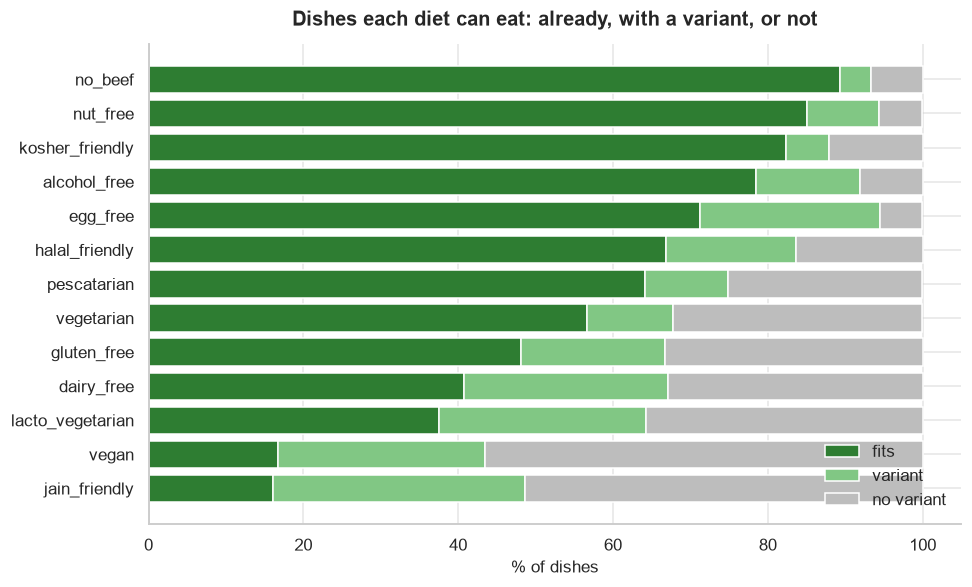

status,fits,variant,no_variant
target,,,
jain_friendly,16.1,32.5,51.4
vegan,16.7,26.8,56.5
lacto_vegetarian,37.5,26.7,35.8
dairy_free,40.8,26.3,32.9
gluten_free,48.1,18.6,33.3
vegetarian,56.7,11.1,32.1
pescatarian,64.1,10.8,25.0
halal_friendly,66.9,16.7,16.4
egg_free,71.2,23.3,5.4


In [6]:
summary = (variants.groupby("target")["status"].value_counts(normalize=True).unstack(fill_value=0)
           .reindex(columns=["fits", "variant", "no_variant"], fill_value=0).mul(100).round(1)
           .sort_values("fits"))
summary.to_csv(VARIANT_SUMMARY_FILE)
fig, ax = plt.subplots(figsize=(9, 5.5))
left = pd.Series(0.0, index=summary.index)
for status, color in [("fits", "#2E7D32"), ("variant", "#81C784"), ("no_variant", "#BDBDBD")]:
    ax.barh(summary.index, summary[status], left=left, color=color, label=status.replace("_", " "))
    left += summary[status]
ax.set_xlabel("% of dishes")
ax.set_title("Dishes each diet can eat: already, with a variant, or not")
ax.legend(loc="lower right", frameon=False)
show_figure(fig, "nb06_01_variant_gains")
summary

In [7]:
missing = needs_change.loc[needs_change["status"] == "no_variant", "missing"].explode().value_counts()
print("Ingredients most often without a safe swap (candidates for GUIDANCE_SWAPS or a team rule):")
print(missing.head(20).to_string())

Ingredients most often without a safe swap (candidates for GUIDANCE_SWAPS or a team rule):
missing
egg yolk                                 22788
cheddar cheese                           21752
mozzarella cheese                        12340
shrimp                                   12004
cream of chicken soup                    10710
ginger                                   10536
cooked chicken                           10335
ham                                       9875
potato                                    9673
worcestershire sauce                      8913
boneless skinless chicken breast half     8780
pork tenderloin                           8666
pork chop                                 7931
beef stock                                7446
prosciutto                                7161
cheese                                    6662
cream of mushroom soup                    6399
ground pork                               6370
feta cheese                               5912
ground t

---

## 5. Hand Check

As with the flags, an AI-made table is checked by a person before any agent uses it. The cell below draws
a blind sample of variants (seed fixed, so the team sees the same rows) to rate: is each swap a sensible
cooking swap, and does the new dish really fit the target?

In [8]:
HAND_CHECK_SIZE = 50
hand_check = needs_change[needs_change["status"] == "variant"].sample(HAND_CHECK_SIZE, random_state=6)
hand_check[["recipe_name", "target", "swaps", "min_reviews"]].head(15)

,recipe_name,target,swaps,min_reviews
2664229,ruby s surprise by kathy stovall,pescatarian,lean ground beef -> veggie crumble,5.0
431685,Breakfast Grits Bowl,halal_friendly,bacon -> olive oil,6.0
1942109,korean salad,vegetarian,bacon -> olive oil; worcestershire sauce -> soy sauce,6.0
2984551,sunshine sandwich,jain_friendly,egg -> flax,6.0
3043624,tapioca custard pudding,lacto_vegetarian,egg -> flax,6.0
2386578,peach cream dessert,lacto_vegetarian,egg -> flax,6.0
169761,Pineapple Lemon Rice,halal_friendly,vanilla extract -> vanilla bean,NaN
814835,bobby flay s roasted vegetable meatloaf with balsamic glaze,kosher_friendly,ground pork -> ground turkey,16.0
2970324,sugar free brownie pudding cake,alcohol_free,vanilla extract -> vanilla bean,NaN
1353003,delicious asian broccoli slaw,gluten_free,soy sauce -> bragg,5.0


---

## 6. Team Decisions and Next Steps

1. **Who hand-checks** the sample of variants (section 5), and the rating rule (sensible swap / fits the diet).
2. **Guidance swaps:** add swaps for the ingredients most often left without one (section 4), each checked
   by a cook; cheese for vegan dishes is the largest gap.
3. **Spin-offs both ways (team idea):** a halal dish's traditional non-halal version, or a vegetarian dish's
   original meat version, from swaps reviewers made in the other direction. Needs a rule for when the
   agent may offer them (only when asked).
4. **Policy P18:** the halal rule applies P18 (alcohol extracts, carmine, rennet), so halal variants
   swap or rule out those too.

---

## Plan status

In [9]:
PLAN = pd.DataFrame([
    ("2 Target diets", f"built: {len(TARGETS)} targets"),
    ("3 Variants for every dish", f"built: {int((variants['status'] == 'variant').sum()):,} variants"),
    ("4 Gains per diet", "built"),
    ("5 Hand check", f"sample of {HAND_CHECK_SIZE} ready; needs a person"),
    ("6 Spin-offs both ways", "planned"),
], columns=["step", "status"])
print(PLAN.to_string(index=False))

                     step                             status
           2 Target diets                  built: 13 targets
3 Variants for every dish            built: 656,611 variants
         4 Gains per diet                              built
             5 Hand check sample of 50 ready; needs a person
    6 Spin-offs both ways                            planned
